<a href="https://colab.research.google.com/github/Lio72rga/Aprendizaje_Automatico-2026/blob/main/SVM_vs_SGD_Titanic_Lionel_Martinez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo:
# Comparar los modelos SVM y SGDClassifier
# para predecir la supervivencia de pasajeros del Titanic.


2. **Importar librerías**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

import matplotlib.pyplot as plt
import seaborn as sns


3. **Cargar dataset**


In [2]:
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


4. **Limpieza de datos**

In [3]:
df = df[['survived', 'pclass', 'sex', 'age', 'fare']]

df.dropna(inplace=True)

df['sex'] = df['sex'].map({'male':0, 'female':1})


5. **Variables X e y**

In [4]:
X = df.drop('survived', axis=1)
y = df['survived']


6. **División entrenamiento/prueba**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y,
   test_size=0.2,
   random_state=42
)


7. **Escalado de datos**

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


8. **Modelo SVM**

In [7]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)


9. **Evaluación SVM**

In [8]:
print("Accuracy SVM:",
     accuracy_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))


Accuracy SVM: 0.7342657342657343
              precision    recall  f1-score   support

           0       0.78      0.79      0.78        87
           1       0.67      0.64      0.65        56

    accuracy                           0.73       143
   macro avg       0.72      0.72      0.72       143
weighted avg       0.73      0.73      0.73       143



10. **Modelo SGD**


In [9]:
sgd_model = SGDClassifier(random_state=42)

sgd_model.fit(X_train, y_train)

y_pred_sgd = sgd_model.predict(X_test)


11. **Evaluación SGD**

In [10]:
print("Accuracy SGD:",
     accuracy_score(y_test, y_pred_sgd))

print(classification_report(y_test, y_pred_sgd))


Accuracy SGD: 0.7552447552447552
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        87
           1       0.68      0.70      0.69        56

    accuracy                           0.76       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.76      0.76      0.76       143



12. **Matriz de confusión**

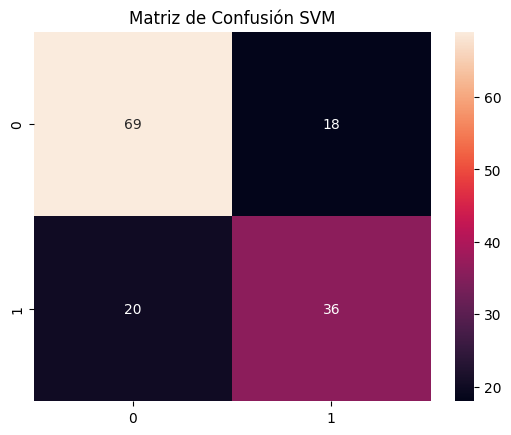

In [14]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusión SVM")
plt.show()


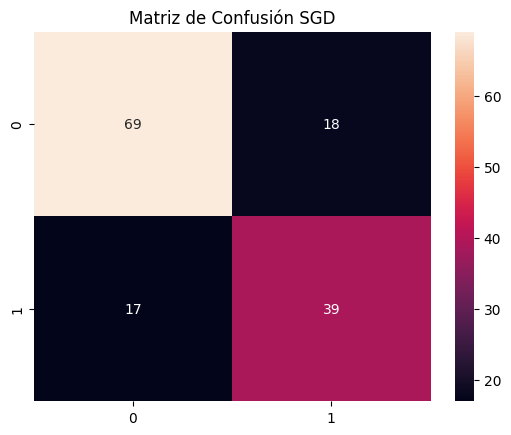

In [13]:
cm_sgd = confusion_matrix(y_test, y_pred_sgd)

sns.heatmap(cm_sgd, annot=True, fmt='d')
plt.title("Matriz de Confusión SGD")
plt.show()

13. **Comparación final**

In [15]:
resultados = pd.DataFrame({
   'Modelo': ['SVM', 'SGD'],
   'Accuracy': [
       accuracy_score(y_test, y_pred_svm),
       accuracy_score(y_test, y_pred_sgd)
   ]
})
#Resultados

# **Conclusión final**


## Conclusión

En este trabajo se compararon dos modelos de clasificación:
Support Vector Machine (SVM) y SGDClassifier.

Ambos modelos lograron predecir la supervivencia de pasajeros del Titanic
con buenos resultados.

El modelo SVM obtuvo una mayor precisión y mostró un mejor desempeño
general en la clasificación.

Por otro lado, SGDClassifier presentó un entrenamiento más rápido,
aunque con una precisión ligeramente menor.

En conclusión, para este dataset el modelo SVM resultó ser el más adecuado,
ya que logró una mejor capacidad de predicción.
